# OccPy tutorial notebook for Terrestrial Laser Scanning (TLS) data

This notebook gives a brief overview over TLS occlusion mapping using OccPy.
The data used for this analysis were acquired using a Riegl VZ400i laser scanner at the Rameren forest close to the WSL in Birmensdorf, Switzerland. The forest plot is characterized as a mixed temperate forest and the data was acquired under leaf-on conditions. The data has been heavily filtered to reduce storage needs and reduce processing time. The tutorial data is the same as used for the manuscript currently under revision in RSE and available as pre-print here: (TODO!)
OccPy can be controlled through a JSON settings file, where all necessary settings are defined for a successful execution of OccPy

First we download the test data and look for the OccPy root folder on your system. All following paths depend on this root directory. 
We further have a look into the JSON settings file to look at its structure

In [1]:
import json
import os
from pathlib import Path
import pooch

# get OccPy root directory
def find_project_root(markers=('README.md','.gitignore','environment.yml','setup.py')):
    try:
        import ipynbname
        current = ipynbname.path().parent
    except Exception:
        current = Path(os.getcwd())

    for parent in [current, *current.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
        
    return current # fallback if nothing found

# Download test data
p = pooch.create(
    path=pooch.os_cache("occpy_test_data"),
    base_url="https://zenodo.org/records/17750604/files/",
    registry={"TLS_demo.zip": "md5:ff15ef6b1b6e655e33c50020089dad56"},
)
p.fetch("TLS_demo.zip", processor=pooch.Unzip(members=["TLS_demo"]), progressbar=True)
data_path = os.path.join(p.path, "TLS_demo.zip.unzip", "TLS_demo")
print(data_path)

occpy_root = find_project_root()
print("Detected occpy root:", occpy_root)

# Load the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_TLS_tutorial.JSON'), 'r') as file:
    settings_orig = json.load(file)
# Display the settings
settings_orig

/Users/danielkukenbrink/Library/Caches/occpy_test_data/TLS_demo.zip.unzip/TLS_demo
Detected occpy root: /Users/danielkukenbrink/dev/OccPy


{'root_folder': '',
 'laz_in': 'data/TLS/LAZ/',
 'tif_in': {'DTM': 'data/Grids/Ramerenwald_DTM_20250305.tif',
  'DSM': 'data/Grids/Ramerenwald_DSM_20250305.tif'},
 'out_dir': 'output/TLS',
 'vox_dim': 0.1,
 'lower_threshold': 1,
 'points_per_iter': 1000000,
 'plot_dim': [2676515, 1246063, 545, 2676525, 1246113, 590],
 'ScanPos': 'data/TLS/ScanPositions.txt',
 'output_voxels': False}

This JSON file can either be modified using your text editor of choice or you could load it into python using the json package and alter the variables within the script, as shown in the following code snippet.
Here is an explanation for the various settings:
- root_folder: root folder of where OccPy is installed -> actually not necessary anymore and can be blank
- laz_in: input laz file - In this case we are expecting a single laz file. If you have multiple laz file (e.g. when using multiple TLS scans), this could be also a directory. See TLS_notebook.ipynb notebook for this case
- tif_in[DTM]: Optional input defining a digital terrain model as a tif file. This is used later for normalization of the output
- tif_in[DSM]: Optional input defining a digital surface model as a tifl file. This is only used in order to give a restriction, until where the canopy is going and will cut off everything above. If this is not needed, you can leave this specification empty. 
        For both surface models: if the extent and resolution does not match the provided plot_dim, it will be cut and transformed to match the voxel grid dimension. It would also expand the terrain/surface models, but I would recommend to always provide a terrain/surface model that is larger in extent than the defined plot_dim
- out_dir: output directory where the output .npy files are stored
- vox_din: voxel size - currently this applies to x, y, and z dimension. Non-cubic voxels are on the list of features to be added
- lower_threshold: height, below which the output will be cut. This can be used to get rid of ground effect on the outputs. 
- points_per_iter: how many points should be loaded in one go. 
- plot_dim: plot dimensions in the format [min_x, min_y, min_z, max_x, max_y, max_z]
- ScanPos: path to the trajectory information (or scan position information for TLS)
- output_voxels: [True/False] if the output should be outputted as ply files - currently not working properly.

In [2]:
import json
import os

# copy original settings into new variable
settings = settings_orig.copy()

# alter root folder
settings['root_folder'] = os.path.abspath(occpy_root)
# update input paths to be relative to the root folder
settings['laz_in'] = os.path.join(data_path, 'LAZ')
settings['tif_in']['DTM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DTM_20250305.tif')
settings['tif_in']['DSM'] = os.path.join(data_path, 'Grids', 'Ramerenwald_DSM_20250305.tif')
settings['ScanPos'] = os.path.join(data_path, 'ScanPos', 'ScanPositions.txt')
settings['out_dir'] = os.path.join(settings['root_folder'], 'output', 'TLS')

# Save the modified settings back to the JSON file
# Save the modified settings back to the JSON file
with open(os.path.join(occpy_root, 'config', 'settings_TLS_tutorial_out.JSON'), 'w') as file:
    json.dump(settings, file, indent=4)

Not necessary, but if you already adapted the json file in a text editor, you can load it here and skip the above step.

In [3]:
def load_config(config_file):
    """Load the configuration from the JSON file."""
    with open(config_file, 'r') as file:
        config = json.load(file)
    return config

config_file = os.path.join(occpy_root, 'config', 'settings_TLS_tutorial_out.JSON')
config = load_config(config_file)

With the settings JSON file all setup, we are now ready to run OccPy on the provided data.
First we have load the OccPy package. Potential messages like 'RIEGL RDBlib is not available' can be ignored, as this is only relevant for when used directly with RIEGL output data


In [4]:
from occpy.OccPy import OccPy

RIEGL RDBlib is not available
RIEGL RiVlib is not available


Now we create an instance of the OccPy Class and prepare it for the voxel traversal 

In [5]:
test = OccPy(laz_in=f"{config['laz_in']}",
             out_dir=config['out_dir'],
             vox_dim=config['vox_dim'],
             lower_threshold=config['lower_threshold'],
             points_per_iter=config['points_per_iter'],
             plot_dim=config['plot_dim'],)

Now we have to define the sensor positions

In [6]:
test.define_sensor_pos(path2file=config['ScanPos'],             # Path to csv file with scanner positions
                       is_mobile=False,                         # Set to True if the scanner is mobile
                       single_return=False,                     # Set to True if the scanner is single return
                       delimiter=',',                           # Delimiter used in the csv file
                       hdr_scanpos_id='ID',                     # Header for the scan position ID [expected an integer that should be linkable to the laz file - number should be in the laz file name]
                       hdr_x='X',                               # Header for the x coordinate
                       hdr_y='Y',                               # Header for the y coordinate
                       hdr_z='Z',                               # Header for the z coordinate
                       sens_pos_id_offset=0,                    # very specific case, where there is an offset between scan position id in the file name and on the ID of the file
                       str_idx_ScanPosID=7,                     # Start index of the scan position ID in the file name, i.e. the file name has the format 'ScanPos033_sort_filtered.laz'. Scan ID is '033'. Therefore str_idx_ScanPosID would be 7
                       str_end_idx_ScanPosID=10)                # End index of the scan position ID in the file name. See explanation for str_idx_ScanPosID. We have to add +1 to the index due to python convention.

Now we can start the raytracing and save the outputs.
Note: This might not be the most performant way to run occlusion mapping for multiple TLS scans. It is beneficial to actually loop over LAZ files and call OccPy for each laz file individually and afterwards merge the results. This alternative approach is shown in the notebook TLS_notebook_individualLAZ.ipynb

In [7]:
import time
tic = time.time()
test.do_raytracing()
toc = time.time()
print(f"Raytracing took {toc - tic:.2f} seconds.")

###############################
##### Processing ScanPos033_sort_filtered.laz...
###############################
  1% [                  ###############################
##### Processing ScanPos061_sort_filtered.laz...
###############################
  1% [                   ###############################
##### Processing ScanPos035_sort_filtered.laz...
###############################
###############################
##### Processing ScanPos047_sort_filtered.laz...
###############################
  1% [            ###############################
##### Processing ScanPos045_sort_filtered.laz...
###############################
convert incomplete pulses to complete ones - be cautious with that!
Run raytracing for incomplete pulses
Time elapsed for raytracing incomplete pulses: 2.76 seconds
Time elapsed for reading and raytracing entire data: 10.80 seconds
Extracting Nhit
#### 16948337 Pulses were traversed of possible 18056952 Pulses
#### 8672978 Returns have been registered by the algorit

We can now height normalize the outputs using the provided DTM and DSM file. The DSM file is only to define the upper bounds of the canopy. Function 'normalize_occlusion_output' will also store the normalized voxel grids as npy files in the specified output folder

In [8]:
from occpy.util import normalize_occlusion_output

Nhit_norm, Nmiss_norm, Nocc_norm, Classification_norm, chm = normalize_occlusion_output(input_folder=config['out_dir'],
                                                                                        PlotDim=config['plot_dim'],
                                                                                        vox_dim=config['vox_dim'],
                                                                                        dtm_file=config['tif_in']['DTM'],
                                                                                        dsm_file=config['tif_in']['DSM'],
                                                                                        lower_threshold=config['lower_threshold'],
                                                                                        output_voxels=config['output_voxels'])

# If instead of a binary voxel grid classification, you are intereded in a fraction of occluded pulses per voxel, you can use the following function:
EPS = 1e-6  # small value to avoid division by zero
OcclFrac_norm = Nocc_norm.astype(float) / (Nhit_norm.astype(float) + Nmiss_norm.astype(float) + Nocc_norm.astype(float) + EPS)


Saving normalized output files into directory as .npy...


We can also visualize the results. Note that the amount of occlusion shown here is very high. This is due to the heavy filtering of the input data consisting of only 20% of the original data. The same figure based on the original data can be seen in the paper Kükenbrink et al. (under revision) [Preprint available here: https://doi.org/10.31223/X5N16X]

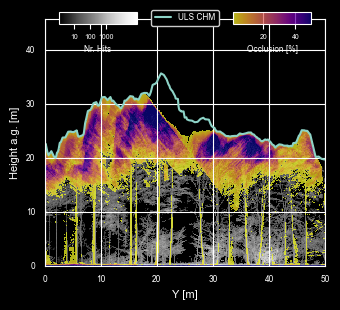

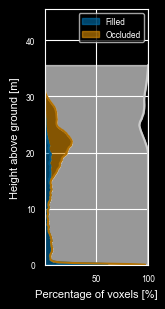

In [9]:
from occpy.visualization import get_Occl_TransectFigure_BinaryOcclusion

# first define figure properties
fig_prop = dict(fig_size=(3.5, 3.2),        # figure size in inches
                label_size=8,               # label size in pts. for e.g. axis labels
                label_size_ticks=6,         # label size in pts. for e.g. axis ticks
                label_size_tiny=5,          # label size in pts. for e.g. ticks in colorbar
                out_format='png',)          # output format of the figure, can be 'png', 'pdf', 'svg', etc.

%matplotlib inline
get_Occl_TransectFigure_BinaryOcclusion(Nhit_norm, Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'],
                                        out_dir=config['out_dir'], axis=0, start_ind=0, end_ind=100, chm=chm, vertBuffer=10, fig_prop=fig_prop, show_plots=True)

# Also get a profile figure of the transect
from occpy.visualization import get_Occlusion_ProfileFigure

# define other figure properties for the smaller figure
fig_prop = dict(fig_size=(1.75, 3.2),
                label_size=8,
                label_size_ticks=6,
                label_size_tiny=5,
                out_format='png', )
get_Occlusion_ProfileFigure(Classification_norm, plot_dim=config['plot_dim'], vox_dim=config['vox_dim'], out_dir=config['out_dir'], low_thresh=0, vertBuffer=10, max_percentage=100, fig_prop=fig_prop, show_plots=True)

The missing part in the middle of the transect close to top of canopy is unobserved volume. This is caused by the few selected Scan stations for the purpose of this tutorial, where all scan stations were setup as vertical scans with the Riegl scanner (no tilted scans). This can lead to unobserved volumes in the canopy. Please see Figure 4 in Kükenbrink et al. (under revision) [Preprint available here: https://doi.org/10.31223/X5N16X] to see how the occlusion map looks like when all scan positions were used.